In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/shavinc241801262/collegedataset/genz_college_admission_prediction.csv


In [4]:
# Load and inspect the College Admission dataset

import pandas as pd
import numpy as np

file_path = "/kaggle/input/datasets/shavinc241801262/collegedataset/genz_college_admission_prediction.csv"

# Load dataset
df = pd.read_csv(file_path)

print("===== DATASET LOADED SUCCESSFULLY =====")
print("Dataset Shape:", df.shape)

print("\n===== FIRST 5 ROWS =====")
display(df.head())

print("\n===== COLUMN NAMES =====")
print(df.columns.tolist())

print("\n===== DATA TYPES & INFORMATION =====")
df.info()

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

print("\n===== DUPLICATE RECORDS =====")
print("Number of duplicates:", df.duplicated().sum())

print("\n===== STATISTICAL SUMMARY =====")
display(df.describe(include="all").T)

===== DATASET LOADED SUCCESSFULLY =====
Dataset Shape: (1000000, 20)

===== FIRST 5 ROWS =====


,student_id,age,gender,state,family_income,high_school_gpa,sat_score,act_score,attendance_rate,ap_courses,extracurricular_count,volunteer_hours,leadership_positions,coding_projects,social_media_hours,online_certifications,essay_score,recommendation_score,interview_score,admission_status
0,1,22,Male,Ohio,32560,3.20,734,27,91.0,3,3,85,1,4,4.8,1,96.3,90.5,71.7,1
1,2,19,Male,Virginia,39084,4.00,988,26,100.0,0,5,103,1,4,2.7,2,59.9,55.2,93.0,1
2,3,20,Male,Ohio,21615,2.90,1600,28,97.7,2,3,78,2,1,5.4,4,75.2,70.3,70.0,1
3,4,22,Male,Illinois,109493,3.86,1302,28,91.6,4,3,98,0,2,1.8,2,80.7,81.9,98.7,1
4,5,18,Male,Florida,50314,2.50,1342,30,91.8,3,4,35,1,2,5.8,3,63.1,73.7,67.5,1



===== COLUMN NAMES =====
['student_id', 'age', 'gender', 'state', 'family_income', 'high_school_gpa', 'sat_score', 'act_score', 'attendance_rate', 'ap_courses', 'extracurricular_count', 'volunteer_hours', 'leadership_positions', 'coding_projects', 'social_media_hours', 'online_certifications', 'essay_score', 'recommendation_score', 'interview_score', 'admission_status']

===== DATA TYPES & INFORMATION =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   student_id             1000000 non-null  int64  
 1   age                    1000000 non-null  int64  
 2   gender                 1000000 non-null  object 
 3   state                  1000000 non-null  object 
 4   family_income          1000000 non-null  int64  
 5   high_school_gpa        1000000 non-null  float64
 6   sat_score              1000000 non-null

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
student_id,1000000.0,NaN,NaN,NaN,500000.5,288675.278933,1.0,250000.75,500000.5,750000.25,1000000.0
age,1000000.0,NaN,NaN,NaN,19.000294,1.999321,16.0,17.0,19.0,21.0,22.0
gender,1000000,3,Male,490475,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,1000000,10,Illinois,100130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
family_income,1000000.0,NaN,NaN,NaN,71701.069023,47253.555181,2124.0,39953.0,59877.0,89688.0,977775.0
high_school_gpa,1000000.0,NaN,NaN,NaN,3.188329,0.476299,0.87,2.86,3.2,3.54,4.0
sat_score,1000000.0,NaN,NaN,NaN,1099.198467,217.409113,400.0,952.0,1100.0,1248.0,1600.0
act_score,1000000.0,NaN,NaN,NaN,23.468139,5.90859,1.0,19.0,24.0,28.0,36.0
attendance_rate,1000000.0,NaN,NaN,NaN,91.748151,5.526156,63.2,88.0,92.0,96.0,100.0
ap_courses,1000000.0,NaN,NaN,NaN,2.999739,1.729285,0.0,2.0,3.0,4.0,12.0


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# -------------------- LOAD DATA --------------------

file_path = "/kaggle/input/datasets/shavinc241801262/collegedataset/genz_college_admission_prediction.csv"

df = pd.read_csv(file_path)

print("=" * 70)
print("COLLEGE ADMISSION DATA ANALYSIS - PHASE 2")
print("=" * 70)

print("\nOriginal Dataset Shape:", df.shape)


COLLEGE ADMISSION DATA ANALYSIS - PHASE 2

Original Dataset Shape: (1000000, 20)


In [7]:
print("\n" + "=" * 70)
print("1. DATA QUALITY ASSESSMENT")
print("=" * 70)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())

print("\nDuplicate Records:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Statistics:")
display(df.describe().T)




1. DATA QUALITY ASSESSMENT

Missing Values:
student_id               0
age                      0
gender                   0
state                    0
family_income            0
high_school_gpa          0
sat_score                0
act_score                0
attendance_rate          0
ap_courses               0
extracurricular_count    0
volunteer_hours          0
leadership_positions     0
coding_projects          0
social_media_hours       0
online_certifications    0
essay_score              0
recommendation_score     0
interview_score          0
admission_status         0
dtype: int64

Total Missing Values: 0

Duplicate Records: 0

Data Types:
student_id                 int64
age                        int64
gender                    object
state                     object
family_income              int64
high_school_gpa          float64
sat_score                  int64
act_score                  int64
attendance_rate          float64
ap_courses                 int64
extracurricu

,count,mean,std,min,25%,50%,75%,max
student_id,1000000.0,500000.500000,288675.278933,1.00,250000.75,500000.5,750000.25,1000000.0
age,1000000.0,19.000294,1.999321,16.00,17.00,19.0,21.00,22.0
family_income,1000000.0,71701.069023,47253.555181,2124.00,39953.00,59877.0,89688.00,977775.0
high_school_gpa,1000000.0,3.188329,0.476299,0.87,2.86,3.2,3.54,4.0
sat_score,1000000.0,1099.198467,217.409113,400.00,952.00,1100.0,1248.00,1600.0
act_score,1000000.0,23.468139,5.908590,1.00,19.00,24.0,28.00,36.0
attendance_rate,1000000.0,91.748151,5.526156,63.20,88.00,92.0,96.00,100.0
ap_courses,1000000.0,2.999739,1.729285,0.00,2.00,3.0,4.00,12.0
extracurricular_count,1000000.0,3.999927,2.001495,0.00,3.00,4.0,5.00,15.0
volunteer_hours,1000000.0,99.452955,50.019098,2.00,63.00,91.0,127.00,517.0


In [8]:
print("\n" + "=" * 70)
print("2. DATA PREPROCESSING")
print("=" * 70)

# Create working copy
clean_df = df.copy()

# Remove duplicates
clean_df = clean_df.drop_duplicates()

# Remove unnecessary ID column
clean_df = clean_df.drop(columns=["student_id"])

# Clean categorical columns
clean_df["gender"] = clean_df["gender"].str.strip().str.title()
clean_df["state"] = clean_df["state"].str.strip().str.title()

# Handle missing numerical values using median
numeric_columns = clean_df.select_dtypes(
    include=["int64", "float64"]
).columns

for column in numeric_columns:
    clean_df[column] = clean_df[column].fillna(
        clean_df[column].median()
    )

# Handle missing categorical values using mode
categorical_columns = clean_df.select_dtypes(
    include=["object"]
).columns

for column in categorical_columns:
    clean_df[column] = clean_df[column].fillna(
        clean_df[column].mode()[0]
    )

print("Duplicates removed:", df.duplicated().sum())
print("Missing values after preprocessing:",
      clean_df.isnull().sum().sum())




2. DATA PREPROCESSING
Duplicates removed: 0
Missing values after preprocessing: 0


In [10]:
print("\n" + "=" * 70)
print("3. OUTLIER DETECTION")
print("=" * 70)

outlier_columns = [
    "family_income",
    "high_school_gpa",
    "sat_score",
    "act_score",
    "attendance_rate",
    "volunteer_hours",
    "essay_score",
    "recommendation_score",
    "interview_score"
]

outlier_results = {}

for column in outlier_columns:

    Q1 = clean_df[column].quantile(0.25)
    Q3 = clean_df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    count = (
        (clean_df[column] < lower_limit) |
        (clean_df[column] > upper_limit)
    ).sum()

    outlier_results[column] = count

print("\nNumber of Outliers:")
for column, count in outlier_results.items():
    print(column, ":", count)



3. OUTLIER DETECTION

Number of Outliers:
family_income : 46397
high_school_gpa : 3107
sat_score : 3454
act_score : 1307
attendance_rate : 3673
volunteer_hours : 21913
essay_score : 3423
recommendation_score : 3550
interview_score : 3311


In [11]:
print("\n" + "=" * 70)
print("4. FEATURE ENGINEERING")
print("=" * 70)

# Academic score
clean_df["academic_score"] = (
    (clean_df["high_school_gpa"] / 4 * 100) * 0.30 +
    (clean_df["sat_score"] / 1600 * 100) * 0.40 +
    (clean_df["act_score"] / 36 * 100) * 0.30
)

# Application score
clean_df["application_score"] = (
    clean_df["essay_score"] * 0.25 +
    clean_df["recommendation_score"] * 0.25 +
    clean_df["interview_score"] * 0.25 +
    clean_df["attendance_rate"] * 0.25
)

# Extracurricular score
clean_df["extracurricular_score"] = (
    clean_df["extracurricular_count"] +
    clean_df["leadership_positions"] +
    clean_df["coding_projects"] +
    clean_df["online_certifications"]
)

print("\nNew Features:")
print("academic_score")
print("application_score")
print("extracurricular_score")




4. FEATURE ENGINEERING

New Features:
academic_score
application_score
extracurricular_score


In [12]:
print("\n" + "=" * 70)
print("5. CATEGORICAL ENCODING")
print("=" * 70)

clean_df["gender_encoded"] = (
    clean_df["gender"].astype("category").cat.codes
)

clean_df["state_encoded"] = (
    clean_df["state"].astype("category").cat.codes
)

print("Categorical encoding completed.")


5. CATEGORICAL ENCODING
Categorical encoding completed.


In [13]:
print("\n" + "=" * 70)
print("6. EXPLORATORY DATA ANALYSIS")
print("=" * 70)

display(
    clean_df.describe().T
)



6. EXPLORATORY DATA ANALYSIS


,count,mean,std,min,25%,50%,75%,max
age,1000000.0,19.000294,1.999321,16.000000,17.000000,19.000,21.000,22.00
family_income,1000000.0,71701.069023,47253.555181,2124.000000,39953.000000,59877.000,89688.000,977775.00
high_school_gpa,1000000.0,3.188329,0.476299,0.870000,2.860000,3.200,3.540,4.00
sat_score,1000000.0,1099.198467,217.409113,400.000000,952.000000,1100.000,1248.000,1600.00
act_score,1000000.0,23.468139,5.908590,1.000000,19.000000,24.000,28.000,36.00
attendance_rate,1000000.0,91.748151,5.526156,63.200000,88.000000,92.000,96.000,100.00
ap_courses,1000000.0,2.999739,1.729285,0.000000,2.000000,3.000,4.000,12.00
extracurricular_count,1000000.0,3.999927,2.001495,0.000000,3.000000,4.000,5.000,15.00
volunteer_hours,1000000.0,99.452955,50.019098,2.000000,63.000000,91.000,127.000,517.00
leadership_positions,1000000.0,1.201223,1.095605,0.000000,0.000000,1.000,2.000,8.00


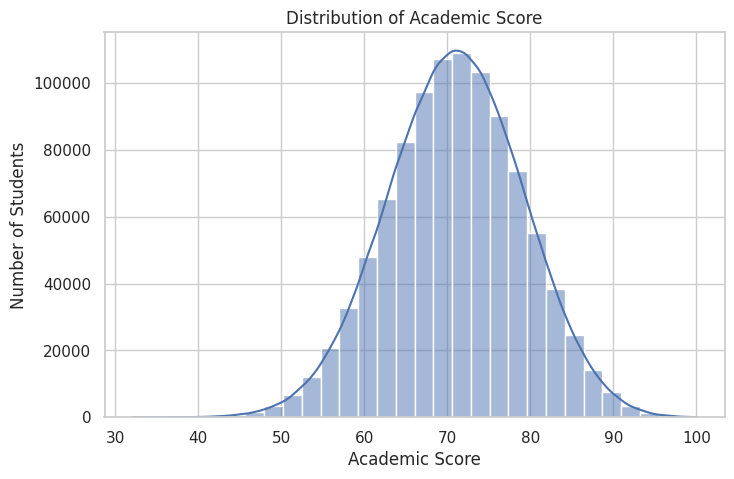

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(
    clean_df["academic_score"],
    bins=30,
    kde=True
)

plt.title("Distribution of Academic Score")
plt.xlabel("Academic Score")
plt.ylabel("Number of Students")
plt.show()

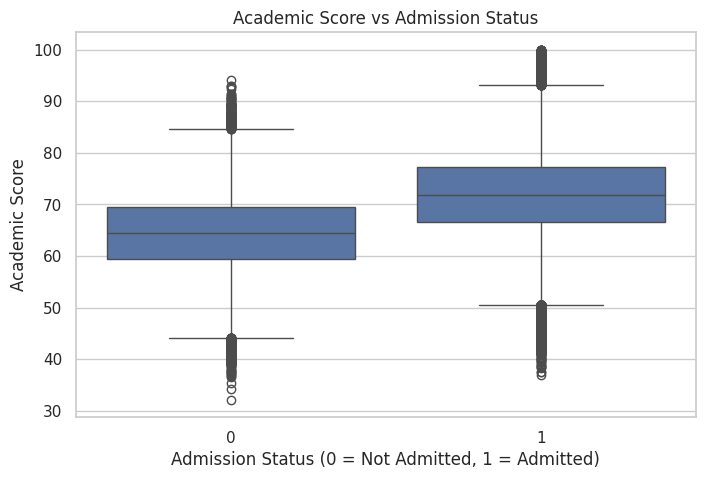

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="admission_status",
    y="academic_score",
    data=clean_df
)

plt.title("Academic Score vs Admission Status")
plt.xlabel("Admission Status (0 = Not Admitted, 1 = Admitted)")
plt.ylabel("Academic Score")
plt.show()

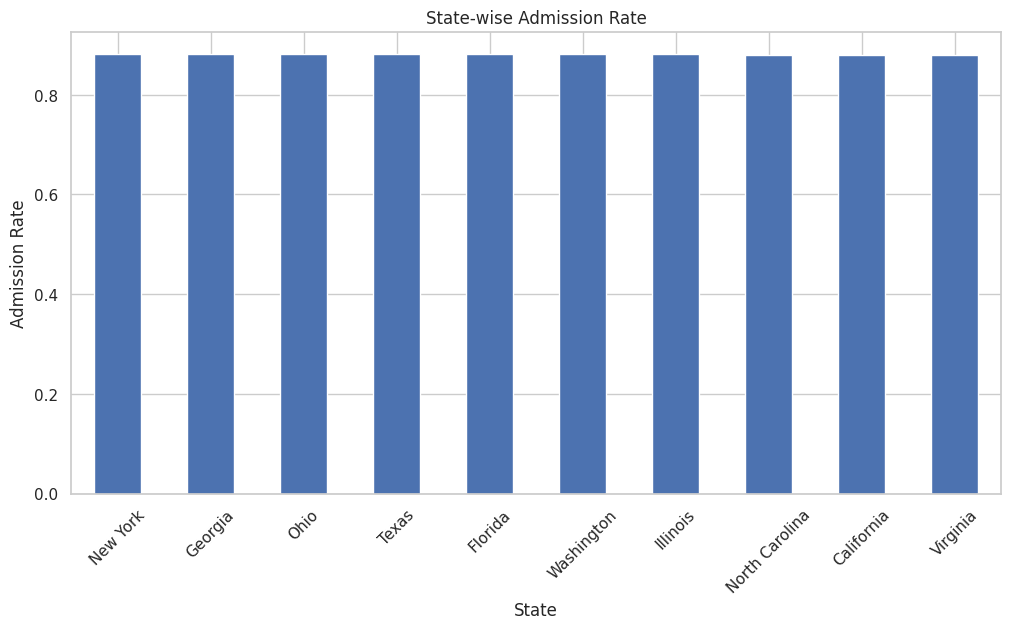

In [16]:
state_admission = (
    clean_df.groupby("state")["admission_status"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

state_admission.plot(kind="bar")

plt.title("State-wise Admission Rate")
plt.xlabel("State")
plt.ylabel("Admission Rate")

plt.xticks(rotation=45)
plt.show()


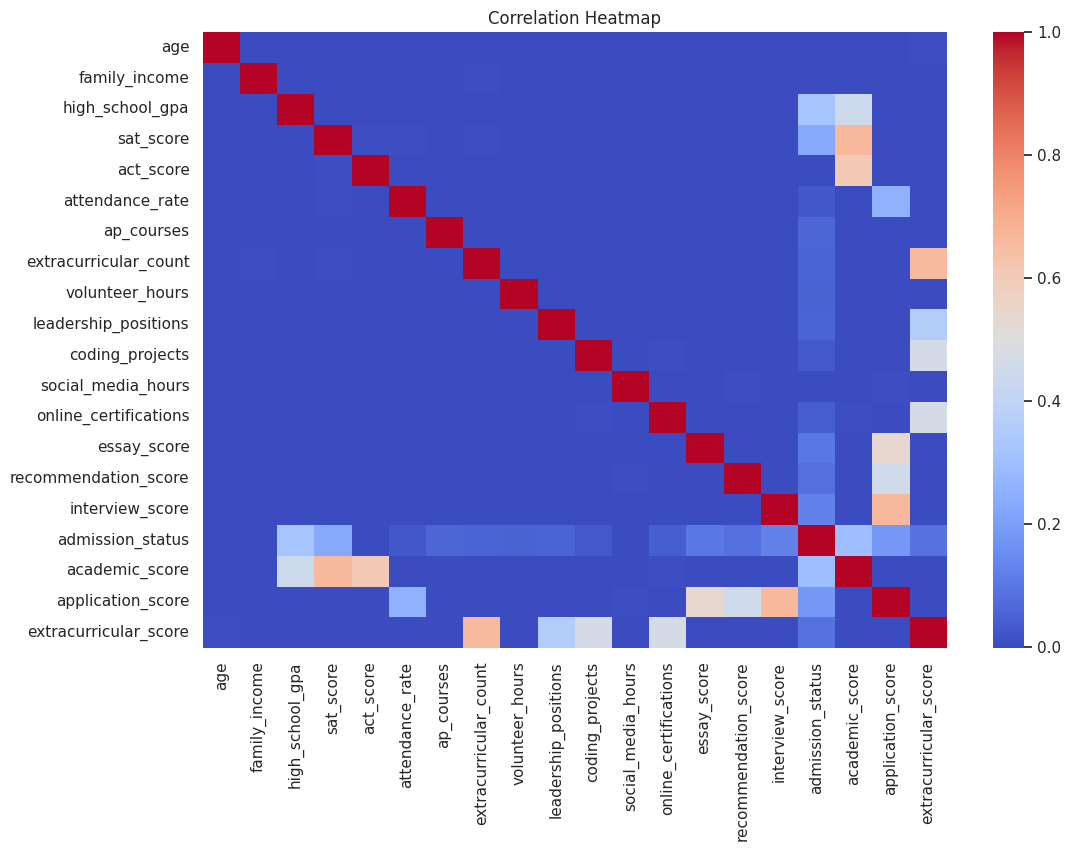

In [17]:
plt.figure(figsize=(12, 8))

correlation = clean_df.select_dtypes(
    include=["int64", "float64"]
).corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()



In [19]:
print("\n" + "=" * 70)
print("KEY INSIGHTS")
print("=" * 70)

admission_rate = clean_df["admission_status"].mean() * 100

print(f"\nOverall Admission Rate: {admission_rate:.2f}%")

print(
    "\nAverage Academic Score of Admitted Students:",
    round(
        clean_df.loc[
            clean_df["admission_status"] == 1,
            "academic_score"
        ].mean(), 2
    )
)

print(
    "Average Academic Score of Non-Admitted Students:",
    round(
        clean_df.loc[
            clean_df["admission_status"] == 0,
            "academic_score"
        ].mean(), 2
    )
)

print("\nFinal Processed Dataset Shape:", clean_df.shape)

print("\nPhase 2 preprocessing and EDA completed successfully!")


KEY INSIGHTS

Overall Admission Rate: 88.13%

Average Academic Score of Admitted Students: 71.84
Average Academic Score of Non-Admitted Students: 64.37

Final Processed Dataset Shape: (1000000, 24)

Phase 2 preprocessing and EDA completed successfully!


COLLEGE ADMISSION DATA ANALYSIS - PHASE 2

Original Dataset Shape: (1000000, 20)

DATA QUALITY ASSESSMENT

Missing Values:
student_id               0
age                      0
gender                   0
state                    0
family_income            0
high_school_gpa          0
sat_score                0
act_score                0
attendance_rate          0
ap_courses               0
extracurricular_count    0
volunteer_hours          0
leadership_positions     0
coding_projects          0
social_media_hours       0
online_certifications    0
essay_score              0
recommendation_score     0
interview_score          0
admission_status         0
dtype: int64

Total Missing Values: 0

Duplicate Records: 0

Data Types:
student_id                 int64
age                        int64
gender                    object
state                     object
family_income              int64
high_school_gpa          float64
sat_score                  int64
act_score                  int64


,count,mean,std,min,25%,50%,75%,max
student_id,1000000.0,500000.500000,288675.278933,1.00,250000.75,500000.5,750000.25,1000000.0
age,1000000.0,19.000294,1.999321,16.00,17.00,19.0,21.00,22.0
family_income,1000000.0,71701.069023,47253.555181,2124.00,39953.00,59877.0,89688.00,977775.0
high_school_gpa,1000000.0,3.188329,0.476299,0.87,2.86,3.2,3.54,4.0
sat_score,1000000.0,1099.198467,217.409113,400.00,952.00,1100.0,1248.00,1600.0
act_score,1000000.0,23.468139,5.908590,1.00,19.00,24.0,28.00,36.0
attendance_rate,1000000.0,91.748151,5.526156,63.20,88.00,92.0,96.00,100.0
ap_courses,1000000.0,2.999739,1.729285,0.00,2.00,3.0,4.00,12.0
extracurricular_count,1000000.0,3.999927,2.001495,0.00,3.00,4.0,5.00,15.0
volunteer_hours,1000000.0,99.452955,50.019098,2.00,63.00,91.0,127.00,517.0



DATA PREPROCESSING AND CLEANSING
Duplicates after cleaning: 0
Missing values after cleaning: 0

OUTLIER DETECTION AND HANDLING

Outliers detected and handled using IQR capping:
family_income: 46397
high_school_gpa: 3107
sat_score: 3454
act_score: 1307
attendance_rate: 3673
volunteer_hours: 21913
essay_score: 3423
recommendation_score: 3550
interview_score: 3311

FEATURE ENGINEERING

New Features Created:
- academic_score
- application_score
- extracurricular_score

CATEGORICAL ENCODING
Categorical encoding completed using One-Hot Encoding.

FINAL DATA VALIDATION

Final Dataset Shape: (1000000, 31)

Total Missing Values: 0

Total Duplicate Records: 0

DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
age,1000000.0,19.000294,1.999321,16.000000,17.000,19.000,21.000,22.00
family_income,1000000.0,69275.601321,38662.986604,2124.000000,39953.000,59877.000,89688.000,164290.50
high_school_gpa,1000000.0,3.188815,0.474777,1.840000,2.860,3.200,3.540,4.00
sat_score,1000000.0,1099.389598,216.853246,508.000000,952.000,1100.000,1248.000,1600.00
act_score,1000000.0,23.470271,5.901619,5.500000,19.000,24.000,28.000,36.00
attendance_rate,1000000.0,91.754887,5.504893,76.000000,88.000,92.000,96.000,100.00
ap_courses,1000000.0,2.999739,1.729285,0.000000,2.000,3.000,4.000,12.00
extracurricular_count,1000000.0,3.999927,2.001495,0.000000,3.000,4.000,5.000,15.00
volunteer_hours,1000000.0,98.701513,47.610020,2.000000,63.000,91.000,127.000,223.00
leadership_positions,1000000.0,1.201223,1.095605,0.000000,0.000,1.000,2.000,8.00



UNIVARIATE ANALYSIS


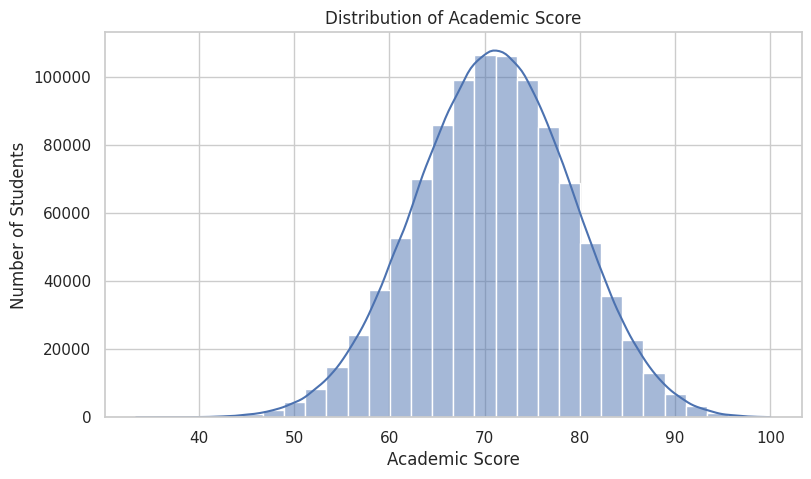

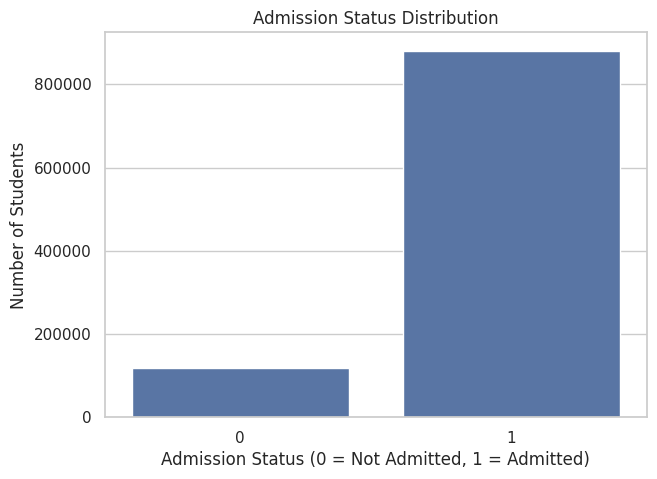


BIVARIATE ANALYSIS


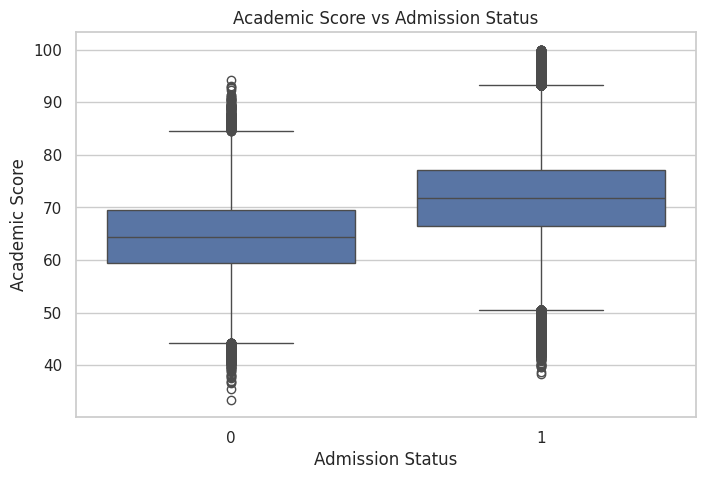

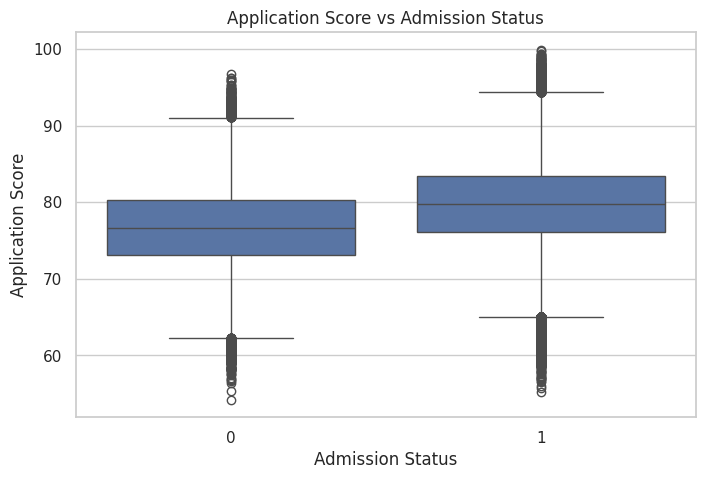

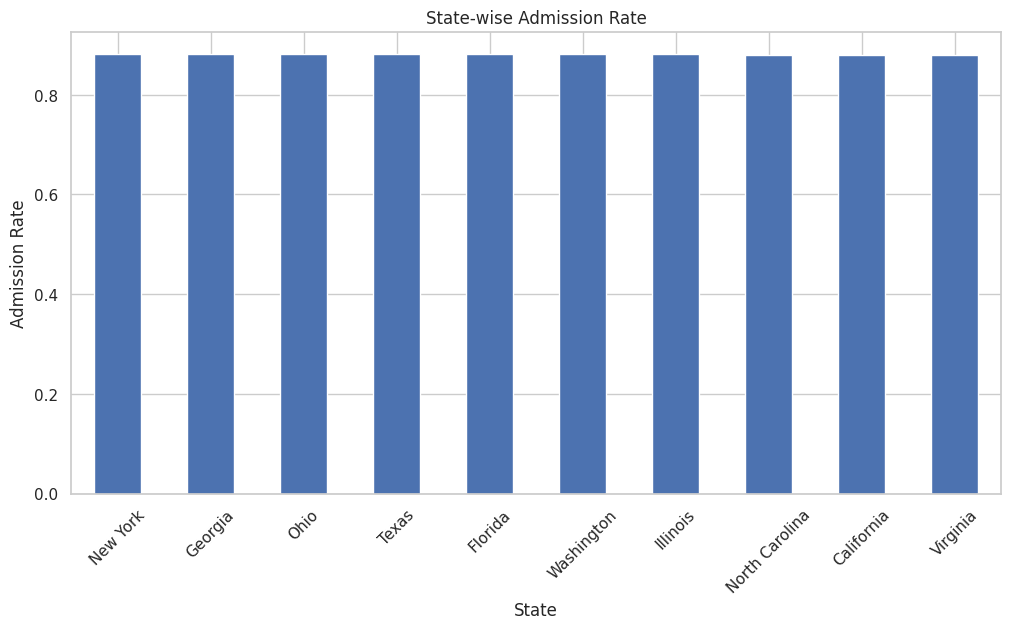


MULTIVARIATE ANALYSIS


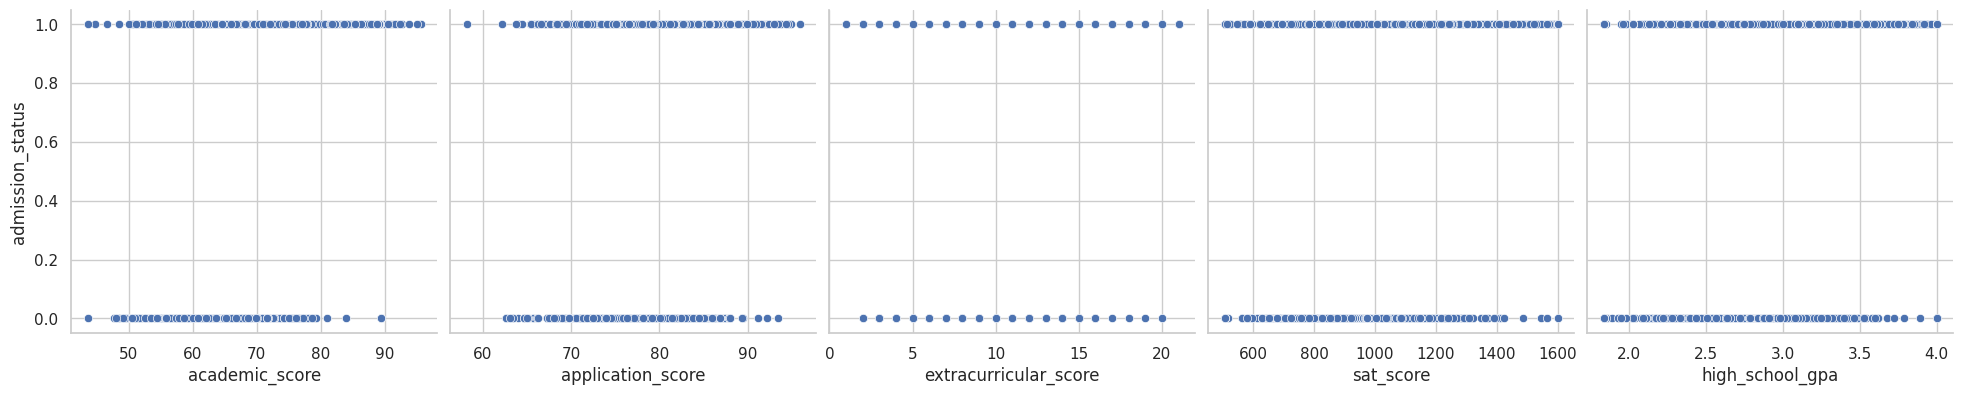


CORRELATION ANALYSIS


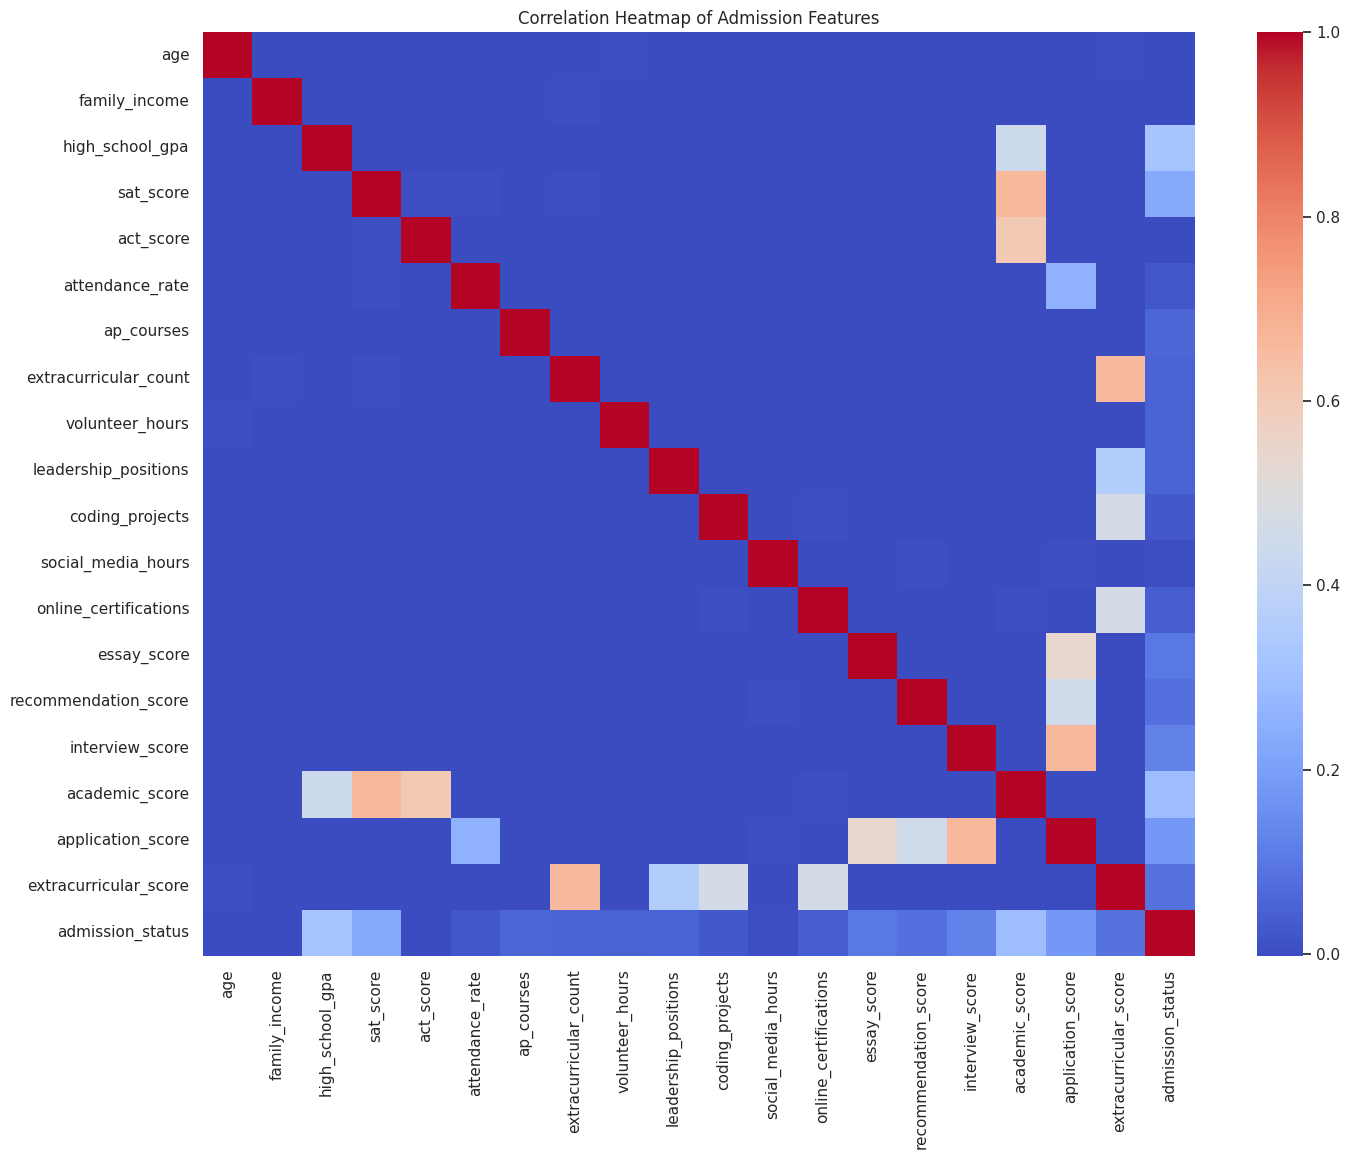


KEY INSIGHTS

Overall Admission Rate: 88.13%

Average Academic Score - Admitted: 71.84
Average Academic Score - Not Admitted: 64.41

Average Application Score - Admitted: 79.72
Average Application Score - Not Admitted: 76.68

Highest State-wise Admission Rate:
state
New York    0.882906
Name: admission_status, dtype: float64

Final Processed Dataset Shape: (1000000, 31)

PHASE 2 COMPLETED SUCCESSFULLY


In [20]:
# ================================================================
# COLLEGE ADMISSION DATA ANALYSIS - PHASE 2
# DATA QUALITY + PREPROCESSING + FEATURE ENGINEERING + EDA
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# ================================================================
# 1. LOAD DATA
# ================================================================

file_path = "/kaggle/input/datasets/shavinc241801262/collegedataset/genz_college_admission_prediction.csv"

df = pd.read_csv(file_path)

print("=" * 70)
print("COLLEGE ADMISSION DATA ANALYSIS - PHASE 2")
print("=" * 70)

print("\nOriginal Dataset Shape:", df.shape)


# ================================================================
# 2. DATA QUALITY ASSESSMENT
# ================================================================

print("\n" + "=" * 70)
print("DATA QUALITY ASSESSMENT")
print("=" * 70)

# Missing values
missing = df.isnull().sum()

print("\nMissing Values:")
print(missing)

print("\nTotal Missing Values:", missing.sum())

# Duplicate records
duplicates = df.duplicated().sum()

print("\nDuplicate Records:", duplicates)

# Data types
print("\nData Types:")
print(df.dtypes)

# Unique values
print("\nUnique Values:")
print(df.nunique())

# Descriptive statistics
print("\nDescriptive Statistics:")
display(df.describe().T)


# ================================================================
# 3. DATA PREPROCESSING AND CLEANSING
# ================================================================

print("\n" + "=" * 70)
print("DATA PREPROCESSING AND CLEANSING")
print("=" * 70)

clean_df = df.copy()

# Remove duplicate records
clean_df = clean_df.drop_duplicates()

# Remove ID column because it is not useful for prediction
clean_df = clean_df.drop(columns=["student_id"])

# Clean categorical values
clean_df["gender"] = clean_df["gender"].astype(str).str.strip().str.title()
clean_df["state"] = clean_df["state"].astype(str).str.strip().str.title()

# Handle missing numerical values
numeric_columns = clean_df.select_dtypes(
    include=["int64", "float64"]
).columns

for column in numeric_columns:
    if clean_df[column].isnull().sum() > 0:
        clean_df[column] = clean_df[column].fillna(
            clean_df[column].median()
        )

# Handle missing categorical values
categorical_columns = clean_df.select_dtypes(
    include=["object"]
).columns

for column in categorical_columns:
    if clean_df[column].isnull().sum() > 0:
        clean_df[column] = clean_df[column].fillna(
            clean_df[column].mode()[0]
        )

print("Duplicates after cleaning:", clean_df.duplicated().sum())
print("Missing values after cleaning:",
      clean_df.isnull().sum().sum())


# ================================================================
# 4. OUTLIER DETECTION AND HANDLING
# ================================================================

print("\n" + "=" * 70)
print("OUTLIER DETECTION AND HANDLING")
print("=" * 70)

outlier_columns = [
    "family_income",
    "high_school_gpa",
    "sat_score",
    "act_score",
    "attendance_rate",
    "volunteer_hours",
    "essay_score",
    "recommendation_score",
    "interview_score"
]

outlier_summary = {}

for column in outlier_columns:

    Q1 = clean_df[column].quantile(0.25)
    Q3 = clean_df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = (
        (clean_df[column] < lower_limit) |
        (clean_df[column] > upper_limit)
    )

    outlier_count = outliers.sum()

    outlier_summary[column] = outlier_count

    # IQR capping / winsorization
    clean_df[column] = clean_df[column].clip(
        lower=lower_limit,
        upper=upper_limit
    )

print("\nOutliers detected and handled using IQR capping:")

for column, count in outlier_summary.items():
    print(f"{column}: {count}")


# ================================================================
# 5. FEATURE ENGINEERING
# ================================================================

print("\n" + "=" * 70)
print("FEATURE ENGINEERING")
print("=" * 70)

# Academic performance score
clean_df["academic_score"] = (
    (clean_df["high_school_gpa"] / 4 * 100) * 0.30 +
    (clean_df["sat_score"] / 1600 * 100) * 0.40 +
    (clean_df["act_score"] / 36 * 100) * 0.30
)

# Application score
clean_df["application_score"] = (
    clean_df["essay_score"] * 0.25 +
    clean_df["recommendation_score"] * 0.25 +
    clean_df["interview_score"] * 0.25 +
    clean_df["attendance_rate"] * 0.25
)

# Extracurricular score
clean_df["extracurricular_score"] = (
    clean_df["extracurricular_count"] +
    clean_df["leadership_positions"] +
    clean_df["coding_projects"] +
    clean_df["online_certifications"]
)

print("\nNew Features Created:")
print("- academic_score")
print("- application_score")
print("- extracurricular_score")


# ================================================================
# 6. CATEGORICAL ENCODING
# ================================================================

print("\n" + "=" * 70)
print("CATEGORICAL ENCODING")
print("=" * 70)

# One-hot encoding for categorical variables
clean_df = pd.get_dummies(
    clean_df,
    columns=["gender", "state"],
    drop_first=True
)

print("Categorical encoding completed using One-Hot Encoding.")


# ================================================================
# 7. FINAL DATA VALIDATION
# ================================================================

print("\n" + "=" * 70)
print("FINAL DATA VALIDATION")
print("=" * 70)

print("\nFinal Dataset Shape:", clean_df.shape)

print("\nTotal Missing Values:",
      clean_df.isnull().sum().sum())

print("\nTotal Duplicate Records:",
      clean_df.duplicated().sum())


# ================================================================
# 8. DESCRIPTIVE STATISTICS
# ================================================================

print("\n" + "=" * 70)
print("DESCRIPTIVE STATISTICS")
print("=" * 70)

display(clean_df.describe().T)


# ================================================================
# 9. UNIVARIATE EDA
# ================================================================

print("\n" + "=" * 70)
print("UNIVARIATE ANALYSIS")
print("=" * 70)

# Academic score distribution
plt.figure(figsize=(9, 5))

sns.histplot(
    clean_df["academic_score"],
    bins=30,
    kde=True
)

plt.title("Distribution of Academic Score")
plt.xlabel("Academic Score")
plt.ylabel("Number of Students")
plt.show()


# Admission status distribution
plt.figure(figsize=(7, 5))

sns.countplot(
    x="admission_status",
    data=clean_df
)

plt.title("Admission Status Distribution")
plt.xlabel("Admission Status (0 = Not Admitted, 1 = Admitted)")
plt.ylabel("Number of Students")
plt.show()


# ================================================================
# 10. BIVARIATE EDA
# ================================================================

print("\n" + "=" * 70)
print("BIVARIATE ANALYSIS")
print("=" * 70)

# Academic score vs admission
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="admission_status",
    y="academic_score",
    data=clean_df
)

plt.title("Academic Score vs Admission Status")
plt.xlabel("Admission Status")
plt.ylabel("Academic Score")
plt.show()


# Application score vs admission
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="admission_status",
    y="application_score",
    data=clean_df
)

plt.title("Application Score vs Admission Status")
plt.xlabel("Admission Status")
plt.ylabel("Application Score")
plt.show()


# ================================================================
# 11. STATE-WISE ADMISSION ANALYSIS
# ================================================================

# Use original cleaned data before one-hot encoding
state_df = df.copy()

state_admission = (
    state_df.groupby("state")["admission_status"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

state_admission.plot(kind="bar")

plt.title("State-wise Admission Rate")
plt.xlabel("State")
plt.ylabel("Admission Rate")

plt.xticks(rotation=45)
plt.show()


# ================================================================
# 12. MULTIVARIATE EDA
# ================================================================

print("\n" + "=" * 70)
print("MULTIVARIATE ANALYSIS")
print("=" * 70)

# Select important numerical features
multi_columns = [
    "high_school_gpa",
    "sat_score",
    "act_score",
    "attendance_rate",
    "essay_score",
    "recommendation_score",
    "interview_score",
    "academic_score",
    "application_score",
    "extracurricular_score",
    "admission_status"
]

# Pairplot using sample to reduce processing time
sample_df = clean_df[multi_columns].sample(
    min(3000, len(clean_df)),
    random_state=42
)

sns.pairplot(
    sample_df,
    y_vars=["admission_status"],
    x_vars=[
        "academic_score",
        "application_score",
        "extracurricular_score",
        "sat_score",
        "high_school_gpa"
    ],
    height=4
)

plt.show()


# ================================================================
# 13. CORRELATION HEATMAP
# ================================================================

print("\n" + "=" * 70)
print("CORRELATION ANALYSIS")
print("=" * 70)

correlation_columns = [
    "age",
    "family_income",
    "high_school_gpa",
    "sat_score",
    "act_score",
    "attendance_rate",
    "ap_courses",
    "extracurricular_count",
    "volunteer_hours",
    "leadership_positions",
    "coding_projects",
    "social_media_hours",
    "online_certifications",
    "essay_score",
    "recommendation_score",
    "interview_score",
    "academic_score",
    "application_score",
    "extracurricular_score",
    "admission_status"
]

correlation = clean_df[correlation_columns].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap of Admission Features")
plt.show()


# ================================================================
# 14. KEY INSIGHTS
# ================================================================

print("\n" + "=" * 70)
print("KEY INSIGHTS")
print("=" * 70)

admission_rate = clean_df["admission_status"].mean() * 100

admitted_academic = clean_df.loc[
    clean_df["admission_status"] == 1,
    "academic_score"
].mean()

not_admitted_academic = clean_df.loc[
    clean_df["admission_status"] == 0,
    "academic_score"
].mean()

admitted_application = clean_df.loc[
    clean_df["admission_status"] == 1,
    "application_score"
].mean()

not_admitted_application = clean_df.loc[
    clean_df["admission_status"] == 0,
    "application_score"
].mean()

print(f"\nOverall Admission Rate: {admission_rate:.2f}%")

print(
    f"\nAverage Academic Score - Admitted: "
    f"{admitted_academic:.2f}"
)

print(
    f"Average Academic Score - Not Admitted: "
    f"{not_admitted_academic:.2f}"
)

print(
    f"\nAverage Application Score - Admitted: "
    f"{admitted_application:.2f}"
)

print(
    f"Average Application Score - Not Admitted: "
    f"{not_admitted_application:.2f}"
)

print("\nHighest State-wise Admission Rate:")
print(state_admission.head(1))

print("\nFinal Processed Dataset Shape:",
      clean_df.shape)

print("\n" + "=" * 70)
print("PHASE 2 COMPLETED SUCCESSFULLY")
print("=" * 70)